## IMPORTS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import sys
import duckdb
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

# Import shared utilities
sys.path.insert(0, os.path.abspath('.'))
from notebook_utils import (
    drop_high_missing_columns, impute_features,
    plot_trajectory_distribution, plot_boxplots_with_stats,
    plot_roc_pr_curves, print_statistical_comparisons, train_repeated_cv, biomarker_summary_stats
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Imports successful")
print("✓ Shared utilities loaded")

✓ Imports successful
✓ Shared utilities loaded


## LOAD DATA

In [2]:
# Connect to HiRiD DuckDB
db_path = '/home/gaga/data/physionet/HiRiD/hirid.duckdb'
conn = duckdb.connect(db_path, read_only=True)

print(f"✓ Connected to HiRiD database: {db_path}")

✓ Connected to HiRiD database: /home/gaga/data/physionet/HiRiD/hirid.duckdb


In [3]:
# Load mechanically ventilated patients
# Define as patients with ventilator mode or PEEP > 0

n_sample_patients = 20000

# Step 1: Get patient IDs on mechanical ventilation
ventilated_query = f"""
SELECT DISTINCT CAST(o.patientid AS INTEGER) as patientid
FROM observations o
WHERE 
    (
        -- Ventilator mode
        o.variableid = '3845'
        -- PEEP > 0
        OR (o.variableid IN ('2600', '2610') AND CAST(o.value AS DOUBLE) > 0)
        -- Tidal volume
        OR (o.variableid IN ('2410', '2400') AND CAST(o.value AS DOUBLE) > 0)
    )
LIMIT {n_sample_patients}
"""

ventilated_patients = conn.execute(ventilated_query).fetchdf()['patientid'].tolist()
print(f"Step 1: Found {len(ventilated_patients):,} mechanically ventilated patients")

# Step 2: Get patient demographics
patient_query = f"""
SELECT 
    CAST(g.patientid AS INTEGER) as patientid,
    CAST(g.admissiontime AS TIMESTAMP) as admission_time,
    g.sex,
    CAST(g.age AS INTEGER) as age,
    g.discharge_status,
    COUNT(DISTINCT o.datetime) as n_observations,
    EPOCH(MAX(CAST(o.datetime AS TIMESTAMP)) - MIN(CAST(o.datetime AS TIMESTAMP))) / 86400.0 as los_days
FROM ref_general_table g
INNER JOIN observations o ON g.patientid = o.patientid
WHERE CAST(g.patientid AS INTEGER) IN {tuple(ventilated_patients)}
GROUP BY g.patientid, g.admissiontime, g.sex, g.age, g.discharge_status
HAVING 
    EPOCH(MAX(CAST(o.datetime AS TIMESTAMP)) - MIN(CAST(o.datetime AS TIMESTAMP))) / 86400.0 >= 2.0
    AND COUNT(DISTINCT o.datetime) >= 100
"""

patient_df = conn.execute(patient_query).fetchdf()

print(f"\n✓ Loaded {len(patient_df):,} ventilated patients")
print(f"  Mean LOS: {patient_df['los_days'].mean():.1f} days")
print(f"  Mean age: {patient_df['age'].mean():.1f} years")

Step 1: Found 20,000 mechanically ventilated patients

✓ Loaded 6,908 ventilated patients
  Mean LOS: 6.7 days
  Mean age: 62.5 years


In [4]:
# Sample subset for analysis
n_patients = min(5000, len(patient_df))
patient_subset = patient_df.sample(n_patients, random_state=920)['patientid'].tolist()

print(f"✓ Using {len(patient_subset):,} patients for analysis")

✓ Using 5,000 patients for analysis


In [5]:
# Load PaO2 (arterial oxygen partial pressure)
pao2_query = f"""
SELECT 
    CAST(o.patientid AS INTEGER) as patientid,
    CAST(o.datetime AS TIMESTAMP) as charttime,
    CAST(o.value AS DOUBLE) as pao2,
    CAST(g.admissiontime AS TIMESTAMP) as admission_time
FROM observations o
INNER JOIN ref_general_table g ON o.patientid = g.patientid
WHERE 
    o.variableid = '20000200'
    AND o.value IS NOT NULL
    AND CAST(o.value AS DOUBLE) > 0
    AND CAST(o.value AS DOUBLE) <= 700  -- Remove outliers (mmHg)
    AND CAST(o.patientid AS INTEGER) IN {tuple(patient_subset)}
ORDER BY o.patientid, o.datetime
"""

pao2_df = conn.execute(pao2_query).fetchdf()
print(f"✓ Loaded {len(pao2_df):,} PaO2 measurements")

# Load FiO2 (fraction of inspired oxygen)
fio2_query = f"""
SELECT 
    CAST(o.patientid AS INTEGER) as patientid,
    CAST(o.datetime AS TIMESTAMP) as charttime,
    CAST(o.value AS DOUBLE) as fio2,
    CAST(g.admissiontime AS TIMESTAMP) as admission_time
FROM observations o
INNER JOIN ref_general_table g ON o.patientid = g.patientid
WHERE 
    o.variableid = '2010'
    AND o.value IS NOT NULL
    AND CAST(o.value AS DOUBLE) >= 21
    AND CAST(o.value AS DOUBLE) <= 100  -- FiO2 as percentage
    AND CAST(o.patientid AS INTEGER) IN {tuple(patient_subset)}
ORDER BY o.patientid, o.datetime
"""

fio2_df = conn.execute(fio2_query).fetchdf()
print(f"✓ Loaded {len(fio2_df):,} FiO2 measurements")

# Merge PaO2 and FiO2 within 1-hour window and calculate P/F ratio
pao2_df['charttime'] = pd.to_datetime(pao2_df['charttime'])
fio2_df['charttime'] = pd.to_datetime(fio2_df['charttime'])

pf_df = pd.merge_asof(
    pao2_df.sort_values('charttime'),
    fio2_df.sort_values('charttime')[['patientid', 'charttime', 'fio2']],
    on='charttime',
    by='patientid',
    tolerance=pd.Timedelta(hours=1),
    direction='nearest'
)

# Calculate P/F ratio
pf_df = pf_df.dropna(subset=['fio2'])
pf_df['pf_ratio'] = (pf_df['pao2'] / pf_df['fio2']) * 100

print(f"\n✓ Calculated P/F ratio for {len(pf_df):,} time points")
print(f"  Patients with P/F ratio: {pf_df['patientid'].nunique():,}")
if len(pf_df) > 0:
    print(f"  Mean P/F ratio: {pf_df['pf_ratio'].mean():.1f}")
    print(f"  Median P/F ratio: {pf_df['pf_ratio'].median():.1f}")

✓ Loaded 113,453 PaO2 measurements
✓ Loaded 12,838,283 FiO2 measurements

✓ Calculated P/F ratio for 88,368 time points
  Patients with P/F ratio: 4,876
  Mean P/F ratio: 217.1
  Median P/F ratio: 202.0


In [6]:
# Load ventilator mode to identify ventilation periods
mode_query = f"""
SELECT 
    CAST(o.patientid AS INTEGER) as patientid,
    CAST(o.datetime AS TIMESTAMP) as charttime,
    o.value as vent_mode,
    CAST(g.admissiontime AS TIMESTAMP) as admission_time
FROM observations o
INNER JOIN ref_general_table g ON o.patientid = g.patientid
WHERE 
    o.variableid = '3845'
    AND o.value IS NOT NULL
    AND CAST(o.patientid AS INTEGER) IN {tuple(patient_subset)}
ORDER BY o.patientid, o.datetime
"""

print("Loading ventilator mode data...")
mode_df = conn.execute(mode_query).fetchdf()

print(f"\n✓ Loaded {len(mode_df):,} ventilator mode records")
print(f"  Patients with mode data: {mode_df['patientid'].nunique():,}")
if len(mode_df) > 0:
    print(f"  Unique modes: {mode_df['vent_mode'].nunique()}")

Loading ventilator mode data...

✓ Loaded 3,439,701 ventilator mode records
  Patients with mode data: 3,932
  Unique modes: 13


In [7]:
# Load SpO2 and respiratory rate for outcome definition
resp_query = f"""
SELECT 
    CAST(o.patientid AS INTEGER) as patientid,
    CAST(o.datetime AS TIMESTAMP) as charttime,
    o.variableid,
    CAST(o.value AS DOUBLE) as value,
    CAST(g.admissiontime AS TIMESTAMP) as admission_time
FROM observations o
INNER JOIN ref_general_table g ON o.patientid = g.patientid
WHERE 
    o.variableid IN (
        '4000', '8280',  -- SpO2
        '300', '310', '5685'  -- Respiratory rate
    )
    AND o.value IS NOT NULL
    AND CAST(o.patientid AS INTEGER) IN {tuple(patient_subset)}
ORDER BY o.patientid, o.datetime
"""

print("Loading respiratory parameters...")
resp_df = conn.execute(resp_query).fetchdf()

print(f"\n✓ Loaded {len(resp_df):,} respiratory parameter measurements")

Loading respiratory parameters...

✓ Loaded 73,224,274 respiratory parameter measurements


In [8]:
# Load vitals and labs - identify available variables from reference table
# Based on HiRiD variable reference, get IDs for key clinical variables

key_vars_query = """
SELECT DISTINCT
    CAST("ID" AS INTEGER) as variableid,
    "Variable Name" as variable_name,
    "Unit" as unit,
    "Source Table" as source_table
FROM ref_hirid_variable_reference
WHERE 
    -- Vitals
    "Variable Name" = 'Heart rate'
    OR "Variable Name" = 'Core body temperature'
    OR "Variable Name" = 'Invasive systolic arterial pressure'
    OR "Variable Name" = 'Invasive diastolic arterial pressure'
    OR "Variable Name" = 'Invasive mean arterial pressure'
    OR "Variable Name" = 'Non-invasive systolic arterial pressure'
    OR "Variable Name" = 'Non-invasive diastolic arterial pressure'
    OR "Variable Name" = 'Non-invasive mean arterial pressure'
    OR "Variable Name" = 'Respiratory rate'
    OR "Variable Name" = 'Peripheral oxygen saturation'
    -- Labs - Blood Chemistry
    OR "Variable Name" = 'Glucose [Moles/volume] in Serum or Plasma'
    OR "Variable Name" = 'Sodium [Moles/volume] in Blood'
    OR "Variable Name" = 'Potassium [Moles/volume] in Blood'
    OR "Variable Name" = 'Chloride [Moles/volume] in Blood'
    OR "Variable Name" = 'Bicarbonate [Moles/volume] in Arterial blood'
    OR "Variable Name" = 'Calcium.ionized [Moles/volume] in Blood'
    OR "Variable Name" = 'Magnesium [Moles/volume] in Blood'
    OR "Variable Name" = 'Phosphate [Moles/volume] in Blood'
    -- Labs - Renal
    OR "Variable Name" = 'Urea [Moles/volume] in Venous blood'
    OR "Variable Name" = 'Creatinine [Moles/volume] in Blood'
    -- Labs - Hematology
    OR "Variable Name" = 'Hemoglobin [Mass/volume] in Blood'
    OR "Variable Name" = 'Leukocytes [#/volume] in Blood'
    OR "Variable Name" = 'Platelets [#/volume] in Blood'
    -- Labs - Coagulation
    OR "Variable Name" = 'INR in Blood by Coagulation assay'
    OR "Variable Name" = 'aPTT in Blood by Coagulation assay'
    -- Labs - Liver/Metabolic
    OR "Variable Name" = 'Bilirubin.total [Moles/volume] in Serum or Plasma'
    OR "Variable Name" = 'Albumin [Mass/volume] in Serum or Plasma'
    -- Labs - Other
    OR "Variable Name" = 'Lactate [Mass/volume] in Arterial blood'
    -- Body measurements
    OR "Variable Name" = 'Body weight'
ORDER BY "Variable Name"
"""

key_vars = conn.execute(key_vars_query).fetchdf()
key_vars['unit'] = key_vars['unit'].fillna('N/A')
print(f"\n📊 Key clinical variables available in HiRiD:")
print(f"{'Variable ID':<12} {'Variable Name':<60} {'Unit':<15}")
print("="*100)
for _, row in key_vars.iterrows():
    print(f"{row['variableid']:<12} {row['variable_name']:<60} {row['unit']:<15}")

print(f"\n✓ Found {len(key_vars)} key clinical variables")

# Create variable ID to column name mapping (handle BP variants properly)
var_id_to_col = {}
for _, row in key_vars.iterrows():
    var_name = row['variable_name']
    var_id = str(row['variableid'])
    
    # Create concise column names, keeping BP types separate
    if 'Invasive systolic' in var_name:
        col_name = 'sbp_invasive'
    elif 'Invasive diastolic' in var_name:
        col_name = 'dbp_invasive'
    elif 'Invasive mean arterial' in var_name:
        col_name = 'mbp_invasive'
    elif 'Non-invasive systolic' in var_name:
        col_name = 'sbp_noninvasive'
    elif 'Non-invasive diastolic' in var_name:
        col_name = 'dbp_noninvasive'
    elif 'Non-invasive mean arterial' in var_name:
        col_name = 'mbp_noninvasive'
    elif 'Heart rate' in var_name:
        col_name = 'heart_rate'
    elif 'temperature' in var_name.lower():
        col_name = 'temperature'
    elif 'Respiratory rate' in var_name:
        col_name = 'respiratory_rate'
    elif 'oxygen saturation' in var_name.lower():
        col_name = 'spo2'
    elif 'Glucose' in var_name:
        col_name = 'glucose'
    elif 'Sodium' in var_name:
        col_name = 'sodium'
    elif 'Potassium' in var_name:
        col_name = 'potassium'
    elif 'Chloride' in var_name:
        col_name = 'chloride'
    elif 'Bicarbonate' in var_name:
        col_name = 'bicarbonate'
    elif 'Calcium' in var_name:
        col_name = 'calcium'
    elif 'Magnesium' in var_name:
        col_name = 'magnesium'
    elif 'Phosphate' in var_name:
        col_name = 'phosphate'
    elif 'Urea' in var_name:
        col_name = 'bun'
    elif 'Creatinine' in var_name:
        col_name = 'creatinine'
    elif 'Hemoglobin' in var_name:
        col_name = 'hemoglobin'
    elif 'Leukocytes' in var_name:
        col_name = 'wbc'
    elif 'Platelets' in var_name:
        col_name = 'platelets'
    elif 'INR' in var_name:
        col_name = 'inr'
    elif 'aPTT' in var_name:
        col_name = 'ptt'
    elif 'Bilirubin' in var_name:
        col_name = 'bilirubin'
    elif 'Albumin' in var_name:
        col_name = 'albumin'
    elif 'Lactate' in var_name:
        col_name = 'lactate'
    elif 'weight' in var_name.lower():
        col_name = 'weight'
    else:
        col_name = var_name.lower().replace(' ', '_')[:30]
    
    var_id_to_col[var_id] = col_name

print(f"\n📋 Variable mapping (ID → Column name):")
for var_id, col_name in sorted(var_id_to_col.items(), key=lambda x: x[1]):
    var_name = key_vars[key_vars['variableid'] == int(var_id)]['variable_name'].iloc[0]
    print(f"   {var_id:>10} → {col_name:25s} ({var_name})")

# Load observations for these variables from the patient subset
var_ids_str = "', '".join(var_id_to_col.keys())
obs_query = f"""
SELECT 
    CAST(o.patientid AS INTEGER) as patientid,
    CAST(o.datetime AS TIMESTAMP) as charttime,
    o.variableid,
    CAST(o.value AS DOUBLE) as value
FROM observations o
WHERE 
    o.variableid IN ('{var_ids_str}')
    AND o.value IS NOT NULL
    AND CAST(o.patientid AS INTEGER) IN {tuple(patient_subset)}
ORDER BY o.patientid, o.datetime
"""

print(f"\n⏳ Loading observations for {len(patient_subset):,} patients...")
obs_df = conn.execute(obs_query).fetchdf()

# Map variable IDs to column names
obs_df['variable'] = obs_df['variableid'].astype(str).map(var_id_to_col)

print(f"\n✓ Loaded {len(obs_df):,} observations")
print(f"  Unique patients: {obs_df['patientid'].nunique():,}")
print(f"  Unique variables: {obs_df['variable'].nunique()}")
print(f"  Time range: {obs_df['charttime'].min()} to {obs_df['charttime'].max()}")

# Show observation counts per variable
print(f"\n📊 Observations per variable:")
var_counts = obs_df.groupby('variable').size().sort_values(ascending=False)
for var_name, count in var_counts.items():
    print(f"   {var_name:25s}: {count:>10,} observations")

# convert creatinine in vitals_labs to mg/dl
obs_df.loc[obs_df['variable'] == 'creatinine', 'value'] = obs_df.loc[obs_df['variable'] == 'creatinine', 'value'] / 88.4


📊 Key clinical variables available in HiRiD:
Variable ID  Variable Name                                                Unit           
24000605     Albumin [Mass/volume] in Serum or Plasma                     g/L            
20004200     Bicarbonate [Moles/volume] in Arterial blood                 mmol/l         
20004300     Bilirubin.total [Moles/volume] in Serum or Plasma            umol/l         
10000400     Body weight                                                  kg             
24000522     Calcium.ionized [Moles/volume] in Blood                      mmol/l         
24000521     Chloride [Moles/volume] in Blood                             mmol/l         
24000439     Chloride [Moles/volume] in Blood                             mmol/l         
410          Core body temperature                                        °C             
20000600     Creatinine [Moles/volume] in Blood                           umol/l         
24000523     Glucose [Moles/volume] in Serum or Plasma

## PREPROCESS

In [9]:
# Calculate baseline P/F ratio (first 24h minimum - lower P/F is worse)
pf_df['charttime'] = pd.to_datetime(pf_df['charttime'])
pf_df['admission_time'] = pd.to_datetime(pf_df['admission_time'])

first_24h = pf_df[pf_df['charttime'] <= pf_df['admission_time'] + pd.Timedelta(hours=24)]

baseline_pf = first_24h.groupby('patientid')['pf_ratio'].min().reset_index()
baseline_pf.columns = ['patientid', 'baseline_pf_ratio']

print(f"\nBaseline P/F ratio:")
print(f"   Patients with baseline: {len(baseline_pf):,}")
print(f"   Mean: {baseline_pf['baseline_pf_ratio'].mean():.1f}")
print(f"   Median: {baseline_pf['baseline_pf_ratio'].median():.1f}")


Baseline P/F ratio:
   Patients with baseline: 4,562
   Mean: 187.7
   Median: 166.7


In [10]:
# Filter patients with sufficient measurements and baseline P/F < 300 (impaired oxygenation)
pf_counts = pf_df.groupby('patientid').size()
valid_patients = pf_counts[pf_counts >= 10].index

baseline_impaired = baseline_pf[baseline_pf['baseline_pf_ratio'] < 300]['patientid']
valid_patients = valid_patients.intersection(baseline_impaired)

pf_filtered = pf_df[pf_df['patientid'].isin(valid_patients)]
patient_final = patient_df[patient_df['patientid'].isin(valid_patients)].merge(
    baseline_pf, on='patientid', how='inner'
)

print(f"\nFiltering:")
print(f"   Patients with ≥10 P/F measurements: {len(patient_final):,}")
print(f"   Mean baseline P/F ratio: {patient_final['baseline_pf_ratio'].mean():.1f}")


Filtering:
   Patients with ≥10 P/F measurements: 2,412
   Mean baseline P/F ratio: 144.6


In [11]:
# Create time series
pf_ts = pf_filtered.merge(
    patient_final[['patientid', 'baseline_pf_ratio', 'admission_time']], 
    on=['patientid', 'admission_time'], 
    how='left'
)

pf_ts['time_days'] = (pf_ts['charttime'] - pf_ts['admission_time']).dt.total_seconds() / 86400
pf_ts['time_day'] = pf_ts['time_days'].astype(int)

# Rename for trajectory script
pf_ts = pf_ts.rename(columns={'pf_ratio': 'lab_value'})
pf_ts = pf_ts.drop_duplicates(subset=['patientid', 'charttime'])

print(f"\n✓ Time series created")
print(f"   Total measurements: {len(pf_ts):,}")
print(f"   Time range: {pf_ts['time_days'].min():.1f} to {pf_ts['time_days'].max():.1f} days")


✓ Time series created
   Total measurements: 55,256
   Time range: -0.0 to 28.0 days


In [12]:
# Save P/F ratio time series for trajectory computation
output_path = '../../results/hirid/ventilator/pf_ratio_timeseries.csv'
os.makedirs(os.path.dirname(output_path), exist_ok=True)

pf_ts.to_csv(output_path, index=False)

print(f"\n✓ Saved P/F ratio time series: {output_path}")
print(f"   Shape: {pf_ts.shape}")


✓ Saved P/F ratio time series: ../../results/hirid/ventilator/pf_ratio_timeseries.csv
   Shape: (55355, 9)


In [12]:
# Merge observations with patient admission times to calculate time_day
obs_df = obs_df.merge(
    patient_final[['patientid', 'admission_time']],
    on='patientid',
    how='inner'
)

obs_df['charttime'] = pd.to_datetime(obs_df['charttime'])
obs_df['admission_time'] = pd.to_datetime(obs_df['admission_time'])
obs_df['time_day'] = ((obs_df['charttime'] - obs_df['admission_time']).dt.total_seconds() / 86400).astype(int)

print(f"\n✓ Calculated time_day for observations")
print(f"  Time range: {obs_df['time_day'].min()} to {obs_df['time_day'].max()} days")

# Define valid ranges for each variable (clinically plausible values)
valid_ranges = {
    # Vitals
    'heart_rate': (20, 250),
    'temperature': (32, 42),
    'sbp_invasive': (40, 250),
    'dbp_invasive': (20, 180),
    'mbp_invasive': (30, 200),
    'sbp_noninvasive': (40, 250),
    'dbp_noninvasive': (20, 180),
    'mbp_noninvasive': (30, 200),
    'respiratory_rate': (4, 60),
    'spo2': (50, 100),
    
    # Labs - Chemistry
    'glucose': (20, 800),      # mg/dL (needs conversion from mmol/L)
    'sodium': (100, 180),      # mmol/L
    'potassium': (1.5, 10),    # mmol/L
    'chloride': (60, 140),     # mmol/L
    'bicarbonate': (5, 50),    # mmol/L
    'calcium': (0.5, 2.0),     # mmol/L (ionized)
    'magnesium': (0.3, 3.0),   # mmol/L
    'phosphate': (0.3, 4.0),   # mmol/L
    
    # Labs - Renal
    'bun': (0.5, 50),          # mmol/L (urea)
    'creatinine': (0.1, 15),  # mg/dL 
    
    # Labs - Hematology
    'hemoglobin': (40, 200),   # g/L
    'wbc': (0.1, 100),         # G/L (10^9/L)
    'platelets': (5, 1500),    # G/L (10^9/L)
    
    # Labs - Coagulation
    'inr': (0.5, 15),
    'ptt': (10, 300),          # seconds (aPTT)
    
    # Labs - Liver
    'bilirubin': (2, 800),     # µmol/L
    'albumin': (10, 60),       # g/L
    
    # Labs - Other
    'lactate': (0.2, 30),      # mmol/L
    'weight': (30, 300),       # kg
}

valid_ranges_df = pd.DataFrame.from_dict(valid_ranges, orient='index', columns=['min', 'max'])

print(f"\n📋 Defined valid ranges for {len(valid_ranges)} variables")

# Filter observations based on valid ranges
obs_df = obs_df.merge(
    valid_ranges_df.reset_index().rename(columns={'index': 'variable'}),
    on='variable',
    how='left'
)
obs_clean = obs_df[obs_df['value'].between(obs_df['min'], obs_df['max'])]

print(f"\n✓ Filtered observations")
print(f"  Before: {len(obs_df):,}")
print(f"  After:  {len(obs_clean):,}")
print(f"  Removed: {len(obs_df) - len(obs_clean):,} ({100*(len(obs_df)-len(obs_clean))/len(obs_df):.1f}%)")

# Aggregate vitals and labs by patient and time_day
# Calculate min, max, mean, std for each variable
print(f"\n⏳ Aggregating observations...")

vitals_labs_agg = obs_clean.pivot_table(
    index=['patientid', 'time_day'],
    columns='variable',
    values='value',
    aggfunc=['min', 'max', 'mean']
)

vitals_labs_agg.columns = [f"{var}_{stat}" for stat, var in vitals_labs_agg.columns]
# ffill imputation
vitals_labs_agg = vitals_labs_agg.sort_index().groupby(level=0).ffill()

vitals_labs_agg = vitals_labs_agg.reset_index()

print(f"\n✓ Aggregated vitals and labs")
print(f"  Shape: {vitals_labs_agg.shape}")
print(f"  Features: {vitals_labs_agg.shape[1] - 2 } (excluding patientid, time_day)")
print(f"  Unique patients: {vitals_labs_agg['patientid'].nunique():,}")
print(f"  Time windows: {len(vitals_labs_agg):,}")


# Drop features with >20% missing values after imputation
missing_pct = vitals_labs_agg.isna().mean()
cols_to_drop = (missing_pct[missing_pct > 0.2].index).tolist()

vitals_labs_clean = vitals_labs_agg.drop(columns=cols_to_drop)

print(f"\n✓ Dropped high-missingness columns (>20%)")
print(f"  Remaining features: {vitals_labs_clean.shape[1] - 2}")
print(f"  Dropped: {vitals_labs_agg.shape[1] - vitals_labs_clean.shape[1]} columns")

# Show which features were kept
feature_cols = [c for c in vitals_labs_clean.columns if c not in ['patientid', 'time_day']]
print(f"\n📊 Kept features ({len(feature_cols)}):")
for col in sorted(feature_cols):
    pct_missing = vitals_labs_clean[col].isna().mean()
    print(f"   {col:40s}: {pct_missing:3.2%} missing")


✓ Calculated time_day for observations
  Time range: 0 to 28 days

📋 Defined valid ranges for 29 variables

✓ Filtered observations
  Before: 111,189,286
  After:  96,625,943
  Removed: 14,563,343 (13.1%)

⏳ Aggregating observations...

✓ Aggregated vitals and labs
  Shape: (20610, 89)
  Features: 87 (excluding patientid, time_day)
  Unique patients: 2,412
  Time windows: 20,610

✓ Dropped high-missingness columns (>20%)
  Remaining features: 66
  Dropped: 21 columns

📊 Kept features (66):
   bicarbonate_max                         : 0.00% missing
   bicarbonate_mean                        : 0.00% missing
   bicarbonate_min                         : 0.00% missing
   bilirubin_max                           : 19.33% missing
   bilirubin_mean                          : 19.33% missing
   bilirubin_min                           : 19.33% missing
   bun_max                                 : 0.96% missing
   bun_mean                                : 0.96% missing
   bun_min                   

In [13]:
patient_final = patient_final.merge(
    vitals_labs_clean,
    on='patientid',
    how='left'
).merge(pf_ts[['patientid', 'time_day', 'lab_value']].rename(columns={'lab_value': 'pf_ratio'}).drop_duplicates(subset=['patientid', 'time_day'], keep='last'),
    on=['patientid', 'time_day'],
    how='left'
)

patient_final = patient_final.drop_duplicates(subset=['patientid', 'time_day'])

patient_final.to_csv('../../results/hirid/ventilator/patient_features.csv', index=False)

## TRAJECTORY MODELING

Run standalone script for SLURM:
```bash
python ../hirid_ventilator_trajs.py --window-days 3.0 --n-batches 10
```

In [14]:
# Load pre-computed trajectory probabilities
trajectory_probs_path = '../../results/hirid/ventilator/ventilator_trajectory_probs_bayes.csv'

if os.path.exists(trajectory_probs_path):
    trajectory_probs = pd.read_csv(trajectory_probs_path)
    print(f"✓ Loaded trajectory probabilities from: {trajectory_probs_path}")
    print(f"   Shape: {trajectory_probs.shape}")
else:
    print(f"⚠️ File not found: {trajectory_probs_path}")
    print("   Run: python ../hirid_ventilator_trajs.py")

✓ Loaded trajectory probabilities from: ../../results/hirid/ventilator/ventilator_trajectory_probs_bayes.csv
   Shape: (14861, 8)


In [15]:
pf_ts = pf_ts.rename(columns={'lab_value': 'pf_ratio'})

In [18]:
trajectory_probs.columns

Index(['patientid', 'time_days', 'time_day', 'lab_value', 'baseline_pf_ratio',
       'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement'],
      dtype='object')

(<Figure size 1400x500 with 2 Axes>,
 (<Axes: title={'center': 'Trajectory Type Distribution'}, ylabel='Number of Observations'>,
  <Axes: title={'center': 'P/F Ratio by Trajectory Type'}, ylabel='P/F Ratio Level'>))

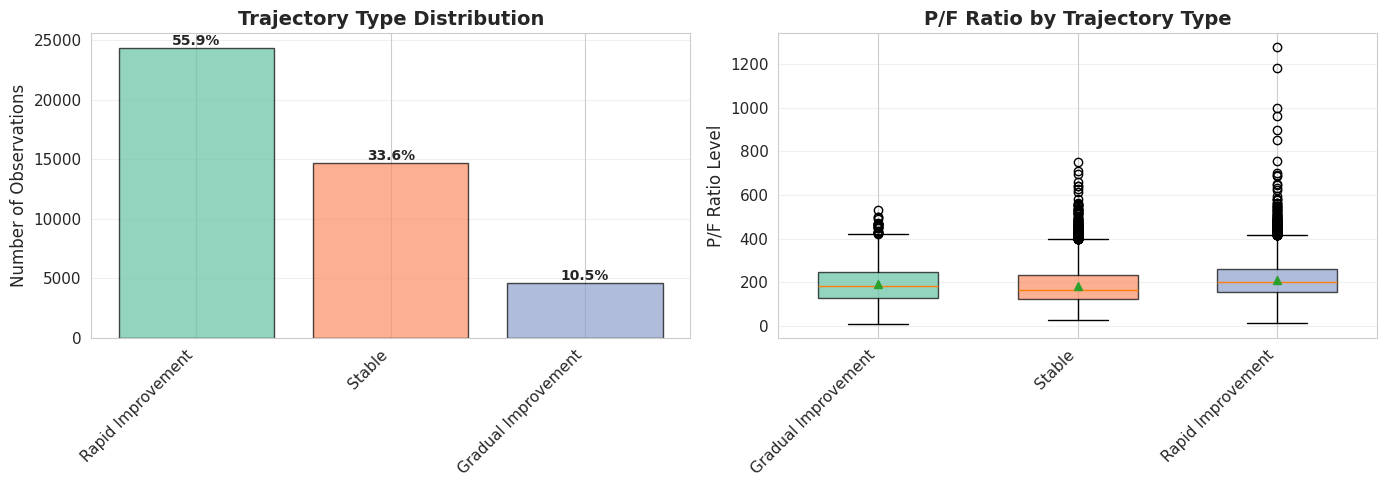

In [19]:
# Visualize trajectory distribution
# Determine dominant trajectory
trajectory_probs['dominant_traj'] = trajectory_probs[[
    'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement'
]].idxmax(axis=1).str.replace('prob_', '')

# Merge with pf_ratio data for visualization
traj_with_pf = trajectory_probs.merge(
    pf_ts[['patientid', 'time_day', 'pf_ratio']],
    on=['patientid', 'time_day'],
    how='left'
)

plot_trajectory_distribution(traj_with_pf,
                              biomarker_col='pf_ratio',
                              biomarker_name='P/F Ratio')

## BIOMARKER SUMMARY STATISTICS

In [16]:
LOOKBACK_DAYS = 3  # Match trajectory window for Ventilator (3 days)
pf_summary_3d = biomarker_summary_stats(pf_ts, 'pf_ratio', lookback_days=LOOKBACK_DAYS)
print(f"\n✓ Calculated P/F ratio summary stats over last {LOOKBACK_DAYS} days")
print(f"   Shape: {pf_summary_3d.shape}")
print(f"   Example stats:\n{pf_summary_3d.head()}")

# Save
pf_summary_3d.to_csv('../../results/hirid/ventilator/pf_ratio_summary_3d.csv', index=False)
print(f"   Saved: pf_ratio_summary_3d.csv")


✓ Calculated P/F ratio summary stats over last 3 days
   Shape: (15291, 8)
   Example stats:
   patientid  time_day  pf_ratio_mean_3d  pf_ratio_max_3d  pf_ratio_min_3d  \
0         11         0        181.308714       215.000000        70.000000   
1         11         1        178.020626       243.362832        70.000000   
2         11         2        180.095963       243.362832        70.000000   
3         14         0        219.577497       285.285285       168.168168   
4         14         1        213.398176       285.285285       168.168168   

   pf_ratio_change_3d  pf_ratio_linear_trend_3d  pf_ratio_std_3d  
0           66.020151                 44.470346        52.008353  
1          173.362832                  6.138045        49.009470  
2          135.000000                  9.663676        47.515878  
3           35.157774                -32.352579        35.655334  
4           29.816718                -21.622426        31.823938  
   Saved: pf_ratio_summary_3d.csv


## DEFINE OUTCOME

Successful ventilator weaning defined as:
1. P/F ratio improved to ≥ 400 (good oxygenation) AND
2. Sustained for 48 hours AND
3. Stable respiratory status (SpO2 ≥ 90%, RR < 30)

In [17]:
# Configuration
PREDICTION_GAP_DAYS = 0.5  # 12-hour gap
PREDICTION_WINDOW_DAYS = 2.0  # Predict successful weaning within 2 days

print(f"📋 Prediction Configuration:")
print(f"   Gap:    {PREDICTION_GAP_DAYS} days")
print(f"   Window: {PREDICTION_WINDOW_DAYS} days")
print(f"   Total:  {PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS} days lookahead")

# Prepare respiratory parameter timing
resp_df['charttime'] = pd.to_datetime(resp_df['charttime'])
resp_df['admission_time'] = pd.to_datetime(resp_df['admission_time'])
resp_df['time_days'] = (resp_df['charttime'] - resp_df['admission_time']).dt.total_seconds() / 86400
resp_df['time_day'] = resp_df['time_days'].astype(int)

# Separate SpO2 and RR
spo2_df = resp_df[resp_df['variableid'].isin(['4000', '8280'])].copy()
rr_df = resp_df[resp_df['variableid'].isin(['300', '310', '5685'])].copy()

print(f"\n✓ Respiratory data prepared")
print(f"  SpO2 measurements: {len(spo2_df):,}")
print(f"  RR measurements: {len(rr_df):,}")

📋 Prediction Configuration:
   Gap:    0.5 days
   Window: 2.0 days
   Total:  2.5 days lookahead

✓ Respiratory data prepared
  SpO2 measurements: 23,902,998
  RR measurements: 49,321,276


In [19]:
# Define waening rediness outcome
weaning_events = []
excluded_counts = {'already_weaned': 0, 'no_future_data': 0}

for patientid, grp in patient_final.groupby('patientid'):
    grp = grp.sort_values('time_day')
    baseline_pf = grp.iloc[0]['pf_ratio']
    
    for i in range(len(grp)):
        current_time = grp.iloc[i]['time_day']
        current_pf_ratio = grp.iloc[i]['pf_ratio']
        
        # Skip if already has good oxygenation (P/F ratio ≥ 400)
        if current_pf_ratio >= 400.0:
            excluded_counts['already_weaned'] += 1
            continue
        
        # Define prediction window
        prediction_start = current_time + PREDICTION_GAP_DAYS + 1
        prediction_end = current_time + PREDICTION_GAP_DAYS + PREDICTION_WINDOW_DAYS + 1
        
        future_window = pf_ts[
            (pf_ts['time_days'].between(prediction_start, prediction_end, inclusive='both')) &
            (pf_ts['patientid'] == patientid)
        ]
        
        if len(future_window) == 0:
            excluded_counts['no_future_data'] += 1
            continue
        
        
        # Weaning readiness: P/F > 300 (simplified)
        weaning_ready = (future_window['pf_ratio'] >= 300).any()
            
        target_weaning = int(weaning_ready)
        
        
        weaning_events.append({
            'patientid': patientid,
            'time_day': current_time,
            'target_successful_weaning': target_weaning,
            'current_pf_ratio': current_pf_ratio,
            'baseline_pf_ratio': baseline_pf,
            'pf_improvement': current_pf_ratio - baseline_pf,
            'prediction_gap_days': PREDICTION_GAP_DAYS,
            'prediction_window_days': PREDICTION_WINDOW_DAYS
        })

weaning_outcomes_df = pd.DataFrame(weaning_events)
positive_first = weaning_outcomes_df[weaning_outcomes_df['target_successful_weaning'] == 1].groupby('patientid').first().reset_index()
all_negatives = weaning_outcomes_df[weaning_outcomes_df['target_successful_weaning'] == 0]
weaning_outcomes_df = pd.concat([all_negatives, positive_first], ignore_index=True).sort_values(['patientid', 'time_day']).reset_index(drop=True)

print(f"\n📊 Outcome Definition Summary:")
print(f"   Total prediction windows: {len(weaning_outcomes_df):,}")
print(f"   Unique patients: {weaning_outcomes_df['patientid'].nunique():,}")
print(f"   \n   Successful Weaning Events:")
print(f"      Total events: {weaning_outcomes_df['target_successful_weaning'].sum():,}")
print(f"      Event rate: {100*weaning_outcomes_df['target_successful_weaning'].mean():.1f}%")


📊 Outcome Definition Summary:
   Total prediction windows: 10,104
   Unique patients: 2,261
   
   Successful Weaning Events:
      Total events: 818
      Event rate: 8.1%


## CONSTRUCT PREDICTION DATASET

In [20]:
patient_final.columns

Index(['patientid', 'admission_time', 'sex', 'age', 'discharge_status',
       'n_observations', 'los_days', 'baseline_pf_ratio', 'time_day',
       'bicarbonate_min', 'bilirubin_min', 'bun_min', 'calcium_min',
       'chloride_min', 'creatinine_min', 'dbp_invasive_min', 'heart_rate_min',
       'hemoglobin_min', 'inr_min', 'lactate_min', 'magnesium_min',
       'mbp_invasive_min', 'phosphate_min', 'platelets_min', 'potassium_min',
       'respiratory_rate_min', 'sbp_invasive_min', 'sodium_min', 'spo2_min',
       'wbc_min', 'weight_min', 'bicarbonate_max', 'bilirubin_max', 'bun_max',
       'calcium_max', 'chloride_max', 'creatinine_max', 'dbp_invasive_max',
       'heart_rate_max', 'hemoglobin_max', 'inr_max', 'lactate_max',
       'magnesium_max', 'mbp_invasive_max', 'phosphate_max', 'platelets_max',
       'potassium_max', 'respiratory_rate_max', 'sbp_invasive_max',
       'sodium_max', 'spo2_max', 'wbc_max', 'weight_max', 'bicarbonate_mean',
       'bilirubin_mean', 'bun_mean', 'c

In [21]:
# Merge trajectory probabilities with outcomes
prediction_dataset = weaning_outcomes_df.copy()


prediction_dataset = weaning_outcomes_df.merge(
        trajectory_probs[[
            'patientid', 'time_day', 
            'prob_stable', 'prob_gradual_improvement', 'prob_rapid_improvement'
        ]],
        on=['patientid', 'time_day'],
        how='left'
    )
prediction_dataset['prob_improving'] = (
        prediction_dataset['prob_gradual_improvement'] + 
        prediction_dataset['prob_rapid_improvement']
    )

# Merge patient demographics
patient_static = patient_final[['patientid', 'age', 'sex']].drop_duplicates(subset=['patientid'])
prediction_dataset = prediction_dataset.merge(
    patient_static,
    on='patientid',
    how='left'
)

# Merge P/F ratio summary statistics
prediction_dataset = prediction_dataset.merge(
    pf_summary_3d.fillna(0),
    on=['patientid', 'time_day'],
    how='left'
)

vitals_labs_features = [
       'bicarbonate_min', 'bilirubin_min', 'bun_min', 'calcium_min',
       'chloride_min', 'creatinine_min', 'dbp_invasive_min', 'heart_rate_min',
       'hemoglobin_min', 'inr_min', 'lactate_min', 'magnesium_min',
       'mbp_invasive_min', 'phosphate_min', 'platelets_min', 'potassium_min',
       'respiratory_rate_min', 'sbp_invasive_min', 'sodium_min', 'spo2_min',
       'wbc_min',  'bicarbonate_max', 'bilirubin_max', 'bun_max',
       'calcium_max', 'chloride_max', 'creatinine_max', 'dbp_invasive_max',
       'heart_rate_max', 'hemoglobin_max', 'inr_max', 'lactate_max',
       'magnesium_max', 'mbp_invasive_max', 'phosphate_max', 'platelets_max',
       'potassium_max', 'respiratory_rate_max', 'sbp_invasive_max',
       'sodium_max', 'spo2_max', 'wbc_max', 'bicarbonate_mean',
       'bilirubin_mean', 'bun_mean', 'calcium_mean', 'chloride_mean',
       'creatinine_mean', 'dbp_invasive_mean', 'heart_rate_mean',
       'hemoglobin_mean', 'inr_mean', 'lactate_mean', 'magnesium_mean',
       'mbp_invasive_mean', 'phosphate_mean', 'platelets_mean',
       'potassium_mean', 'respiratory_rate_mean', 'sbp_invasive_mean',
       'sodium_mean', 'spo2_mean', 'wbc_mean', 'weight_mean', 'pf_ratio']

# Merge vitals/labs features
prediction_dataset = prediction_dataset.merge(
    patient_final[['patientid', 'time_day'] + vitals_labs_features].drop_duplicates(subset=['patientid', 'time_day']),
    on=['patientid', 'time_day'],
    how='left'
)

# Backfill weight only
prediction_dataset['weight_mean'] = prediction_dataset.groupby('patientid')['weight_mean'].bfill()

# define pf change/improvement feature
prediction_dataset['pf_improvement'] = prediction_dataset['pf_ratio'] - prediction_dataset['baseline_pf_ratio']



print(f"\n📋 Final Prediction Dataset:")
print(f"   Rows: {len(prediction_dataset):,}")
print(f"   Columns: {len(prediction_dataset.columns)}")
print(f"   Unique patients: {prediction_dataset['patientid'].nunique():,}")

# Save
os.makedirs('../../results/hirid/ventilator', exist_ok=True)
prediction_dataset.to_csv('../../results/hirid/ventilator/ventilator_prediction_dataset.csv', index=False)
print(f"\n✓ Saved: results/hirid/ventilator/ventilator_prediction_dataset.csv")


📋 Final Prediction Dataset:
   Rows: 10,104
   Columns: 85
   Unique patients: 2,261

✓ Saved: results/hirid/ventilator/ventilator_prediction_dataset.csv


## FIT MODELS

In [22]:
# Define feature sets (11 combinations matching MIMIC pipeline)
feature_sets = {
    'Trajectory Only': [
        'prob_stable',
        'prob_gradual_improvement',
        'prob_rapid_improvement',
        'prob_improving'
    ],
    
    'Summary Stats Only': [col for col in pf_summary_3d.columns if col not in ['patientid', 'time_day']],
    
    'Trajectory + Summary Stats': [
        'prob_stable',
        'prob_gradual_improvement',
        'prob_rapid_improvement',
        'prob_improving'
    ] + [col for col in pf_summary_3d.columns if col not in ['patientid', 'time_day']],
    
    'Static Only': [
        'pf_improvement',
        'baseline_pf_ratio',
        'age',
        'sex'
    ],
    
    'Trajectory + Static': [
        'prob_stable',
        'prob_gradual_improvement',
        'prob_rapid_improvement',
        'prob_improving',
        'baseline_pf_ratio',
        'pf_improvement',
        'age',
        'sex'
    ],
    
    'Summary Stats + Static': [col for col in pf_summary_3d.columns if col not in ['patientid', 'time_day']] + [
        'pf_improvement',
        'baseline_pf_ratio',
        'age',
        'sex'
    ],
    
    'Trajectory + Summary Stats + Static': [
        'prob_stable',
        'prob_gradual_improvement',
        'prob_rapid_improvement',
        'prob_improving'
    ] + [col for col in pf_summary_3d.columns if col not in ['patientid', 'time_day']] + [
        'pf_improvement',
        'baseline_pf_ratio',
        'age',
        'sex'
    ],
    
    'Static + Dynamic': [
        'pf_improvement',
        'baseline_pf_ratio',
        'age',
        'sex'
    ] + vitals_labs_features,
    
    'Trajectory + Static + Dynamic': [
        'prob_stable',
        'prob_gradual_improvement',
        'prob_rapid_improvement',
        'prob_improving',
        'baseline_pf_ratio',
        'pf_improvement',
        'age',
        'sex'
    ] + vitals_labs_features,
    
    'Summary Stats + Static + Dynamic': [col for col in pf_summary_3d.columns if col not in ['patientid', 'time_day']] + [
        'pf_improvement',
        'baseline_pf_ratio',
        'age',
        'sex'
    ] + vitals_labs_features,
    
    'Trajectory + Summary Stats + Static + Dynamic': [
        'prob_stable',
        'prob_gradual_improvement',
        'prob_rapid_improvement',
        'prob_improving'
    ] + [col for col in pf_summary_3d.columns if col not in ['patientid', 'time_day']] + [
        'pf_improvement',
        'baseline_pf_ratio',
        'age',
        'sex'
    ] + vitals_labs_features,
}

print(f"📋 Feature Set Summary (11 combinations):")
for name, features in feature_sets.items():
    print(f"   {name:45s}: {len(features):3d} features")

📋 Feature Set Summary (11 combinations):
   Trajectory Only                              :   4 features
   Summary Stats Only                           :   6 features
   Trajectory + Summary Stats                   :  10 features
   Static Only                                  :   4 features
   Trajectory + Static                          :   8 features
   Summary Stats + Static                       :  10 features
   Trajectory + Summary Stats + Static          :  14 features
   Static + Dynamic                             :  69 features
   Trajectory + Static + Dynamic                :  73 features
   Summary Stats + Static + Dynamic             :  75 features
   Trajectory + Summary Stats + Static + Dynamic:  79 features


In [23]:
# Prepare data for modeling
all_feature_cols = list(set([feat for features in feature_sets.values() for feat in features]))
prediction_clean = prediction_dataset.dropna(subset=['target_successful_weaning']).copy()

if 'sex' in prediction_clean.columns:
    prediction_clean['sex'] = prediction_clean['sex'].map({'m': 1, 'f': 0, 'M': 1, 'F': 0})

# Intelligent imputation strategy
# Trajectory probabilities: forward fill within patient with limit (recent trajectory state persists)
traj_cols = ['prob_stable',
        'prob_gradual_improvement',
        'prob_rapid_improvement',
        'prob_improving']
for col in traj_cols:
    if col in prediction_clean.columns:
        prediction_clean[col] = prediction_clean.groupby('patientid')[col].fillna(method='ffill', limit=2)
        prediction_clean[col] = prediction_clean[col].fillna(0)  # Unknown states → 0


y = prediction_clean['target_successful_weaning']
groups = prediction_clean['patientid']

print(f"\n📋 Final Dataset for Modeling:")
print(f"   Total samples: {len(y):,}")
print(f"   Positive class: {y.sum():,} ({100*y.mean():.1f}%)")
print(f"   Unique patients: {groups.nunique():,}")
print(f"\nImputation strategy:")
print(f"   Trajectories: ffill limit=2, then 0 (recent state persists)")
print(f"   Summary stats: ffill limit=2 (avoid stale aggregates)")
print(f"   Vitals/Labs: ffill limit=3 (carry forward measurements)")
print(f"   Remaining: median imputation")


📋 Final Dataset for Modeling:
   Total samples: 10,104
   Positive class: 818 (8.1%)
   Unique patients: 2,261

Imputation strategy:
   Trajectories: ffill limit=2, then 0 (recent state persists)
   Summary stats: ffill limit=2 (avoid stale aggregates)
   Vitals/Labs: ffill limit=3 (carry forward measurements)
   Remaining: median imputation


## EVALUATE

In [24]:
y.unique()

array([0, 1])

In [25]:
# Repeated Cross-validation
n_repeats = 10
n_folds = 5
n_folds_total = n_repeats * n_folds

comparison_results = {}

print(f"\n🎯 Training models with {n_repeats}-Repeat {n_folds}-Fold CV:\n")

for feature_set_name, feature_cols in feature_sets.items():
    print(f"{feature_set_name}")
    print("-" * 60)
    
    fold_metrics = train_repeated_cv(
        prediction_df=prediction_clean,
        feature_cols=feature_cols,
        target_col='target_successful_weaning',
        group_col='patientid',
        n_repeats=n_repeats,
        n_folds=n_folds,
        random_state=920
    )
    
    comparison_results[feature_set_name] = fold_metrics
    
    print(f"  AUROC:   {np.mean(fold_metrics['roc_auc']):.3f} ± {np.std(fold_metrics['roc_auc']):.3f}")
    print(f"  AUPR:    {np.mean(fold_metrics['avg_precision']):.3f} ± {np.std(fold_metrics['avg_precision']):.3f}\n")


🎯 Training models with 10-Repeat 5-Fold CV:

Trajectory Only
------------------------------------------------------------
  AUROC:   0.702 ± 0.019
  AUPR:    0.191 ± 0.021

Summary Stats Only
------------------------------------------------------------
  AUROC:   0.799 ± 0.009
  AUPR:    0.331 ± 0.031

Trajectory + Summary Stats
------------------------------------------------------------
  AUROC:   0.803 ± 0.006
  AUPR:    0.349 ± 0.017

Static Only
------------------------------------------------------------
  AUROC:   0.812 ± 0.013
  AUPR:    0.390 ± 0.044

Trajectory + Static
------------------------------------------------------------
  AUROC:   0.806 ± 0.006
  AUPR:    0.395 ± 0.035

Summary Stats + Static
------------------------------------------------------------
  AUROC:   0.828 ± 0.009
  AUPR:    0.415 ± 0.046

Trajectory + Summary Stats + Static
------------------------------------------------------------
  AUROC:   0.825 ± 0.006
  AUPR:    0.401 ± 0.039

Static + Dynamic



📊 Performance Summary:
                                        Model         AUROC          AUPR
                              Trajectory Only 0.702 ± 0.019 0.191 ± 0.021
                           Summary Stats Only 0.799 ± 0.009 0.331 ± 0.031
                   Trajectory + Summary Stats 0.803 ± 0.006 0.349 ± 0.017
                                  Static Only 0.812 ± 0.013 0.390 ± 0.044
                          Trajectory + Static 0.806 ± 0.006 0.395 ± 0.035
                       Summary Stats + Static 0.828 ± 0.009 0.415 ± 0.046
          Trajectory + Summary Stats + Static 0.825 ± 0.006 0.401 ± 0.039
                             Static + Dynamic 0.823 ± 0.013 0.421 ± 0.037
                Trajectory + Static + Dynamic 0.822 ± 0.010 0.409 ± 0.036
             Summary Stats + Static + Dynamic 0.828 ± 0.013 0.413 ± 0.042
Trajectory + Summary Stats + Static + Dynamic 0.828 ± 0.015 0.414 ± 0.040

✓ Saved: results/hirid/ventilator/model_comparison_curves.png


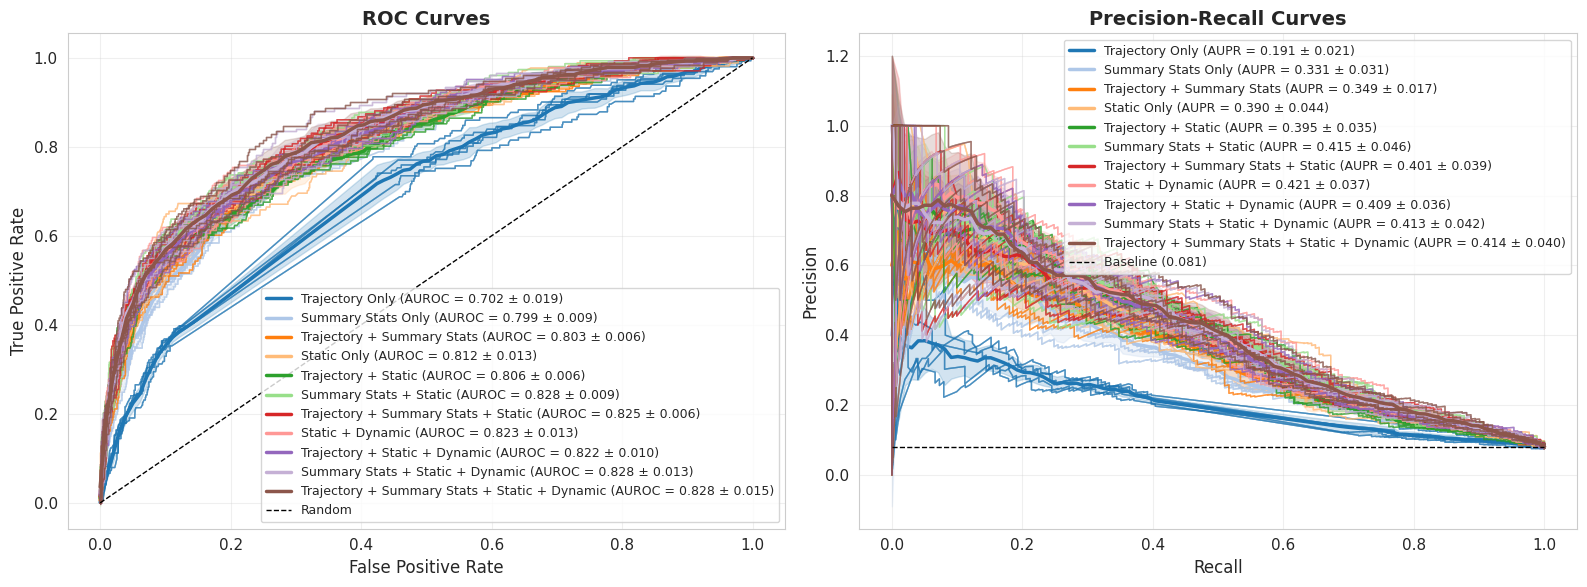

In [27]:
# Performance comparison
summary_df = pd.DataFrame([
    {
        'Model': name,
        'AUROC': f"{np.mean(metrics['roc_auc']):.3f} ± {np.std(metrics['roc_auc']):.3f}",
        'AUPR': f"{np.mean(metrics['avg_precision']):.3f} ± {np.std(metrics['avg_precision']):.3f}"
    }
    for name, metrics in comparison_results.items()
])

print("\n📊 Performance Summary:")
print(summary_df.to_string(index=False))

# ROC & PR Curves
fig, (ax1, ax2) = plot_roc_pr_curves(
    comparison_results=comparison_results,
    outcome_df=prediction_clean,
    target_col='target_successful_weaning',
    color_scheme='tab20'
)
plt.savefig('../../results/hirid/ventilator/model_comparison_curves.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/hirid/ventilator/model_comparison_curves.png")
plt.show()


✓ Saved: results/hirid/ventilator/model_comparison_boxplots.png


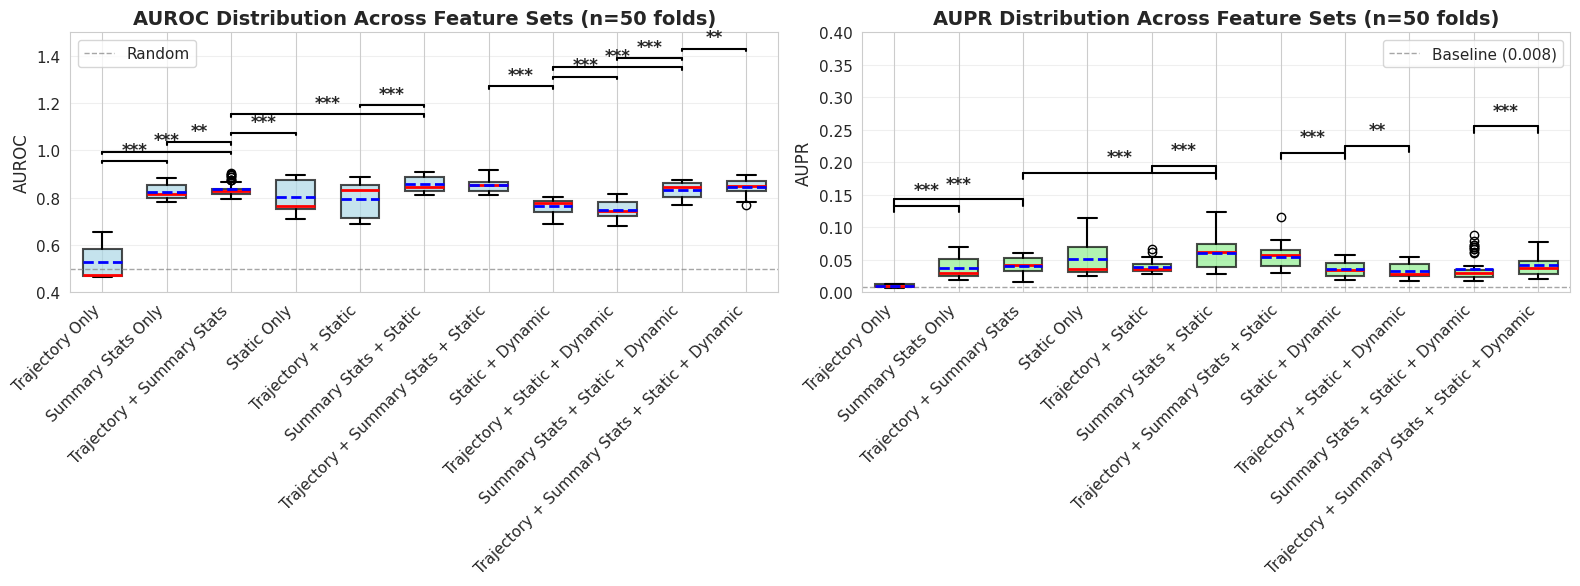


PAIRWISE STATISTICAL COMPARISONS (Wilcoxon Signed-Rank Test)
Comparison                                                   AUROC p      Sig   AUPR p       Sig  
--------------------------------------------------------------------------------
Trajectory Only vs Summary Stats Only                        0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.2960        +0.0274
Trajectory Only vs Trajectory + Summary Stats                0.0000       ***   0.0000       ***  
  Effect size (Δ):                                           +0.3069        +0.0304
Summary Stats Only vs Trajectory + Summary Stats             0.0013       **    0.2491            
  Effect size (Δ):                                           +0.0109        +0.0029
Trajectory + Summary Stats vs Static Only                    0.0004       ***   0.1232            
  Effect size (Δ):                                           -0.0348        +0.0107
Trajectory + Summary Stats

In [47]:
# Statistical significance testing
pairs_to_compare = [
    (0, 1),  # Trajectory vs Summary
    (0, 2),  # Trajectory vs Trajectory + Summary
    (1, 2),  # Summary vs Trajectory + Summary
    (2, 3),  # Trajectory + Summary vs Static Only
    (2, 4),  # Trajectory + Summary vs Trajectory + Static
    (2, 5),  # Trajectory + Summary vs Summary + Static
    (4, 5),  # Trajectory + Static vs Summary + Static

    (5, 6),  # Summary + Static vs Trajectory + Summary + Static
    (6, 7),  # Trajectory + Summary + Static vs Static + Dynamic
    (7, 8),  # Static + Dynamic vs Trajectory + Static + Dynamic
    (7, 9),  # Static + Dynamic vs Summary + Static + Dynamic
    (8, 9),  # Trajectory + Static + Dynamic vs Summary + Static + Dynamic
    (9, 10), # Summary + Static + Dynamic vs Trajectory + Summary + Static + Dynamic
    ]

fig, (ax1, ax2) = plot_boxplots_with_stats(
    comparison_results=comparison_results,
    outcome_df=prediction_clean,
    target_col='target_successful_weaning',
    pairs_to_compare=pairs_to_compare,
    n_folds_total=n_folds_total,
    roc_ylim=(0.4, 1.5),
    ap_ylim=(0.0, 0.4)
)
plt.savefig('../../results/hirid/ventilator/model_comparison_boxplots.png', dpi=300, bbox_inches='tight')
print("\n✓ Saved: results/hirid/ventilator/model_comparison_boxplots.png")
plt.show()

print_statistical_comparisons(
    comparison_results=comparison_results,
    pairs_to_compare=pairs_to_compare
)